## **Statistical Analysis**

In [27]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

In [28]:
df_features

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1


In [5]:
df_target

0      1
1      1
2      1
3      1
4      1
      ..
294    0
295    0
296    0
297    0
298    0
Name: DEATH_EVENT, Length: 299, dtype: int64

In [6]:
df_features.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object')

In [7]:
# correlation of the features with the output 
from scipy.stats import pearsonr
# pearsonr = calculates the Pearson correlation coefficient (r) and the p-value for testing non-correlation between two datasets

features = []
correlations = []
p_values = []
target_variable = 'DEATH_EVENT'

for column in df.columns:
    if column != target_variable:
        corr, p_val = pearsonr(df[column], df[target_variable])
        features.append(column)
        correlations.append(corr)
        p_values.append(p_val)

# create a DataFrame to display the results
results_df = pd.DataFrame({
    'Feature': features,
    'Pearson Correlation': correlations,
    'P-value': p_values
})
results_df_sorted = results_df.sort_values(by='Pearson Correlation', ascending=False)
results_df_sorted

,Feature,Pearson Correlation,P-value
7,serum_creatinine,0.294278,2.190198e-07
0,age,0.253729,8.916763e-06
5,high_blood_pressure,0.079351,1.711495e-01
1,anaemia,0.066270,2.532988e-01
2,creatinine_phosphokinase,0.062728,2.796112e-01
3,diabetes,-0.001943,9.733118e-01
9,sex,-0.004316,9.407519e-01
10,smoking,-0.012623,8.279207e-01
6,platelets,-0.049139,3.971942e-01
8,serum_sodium,-0.195204,6.889112e-04


**Summary:** 

- Features with p-value > 0.05 are statistically insignificant and should be 
excluded from the model (diabetes, sex, smoking, platelets).

- Features with high pearson correlation coefficients (|r| > 0.25, p < 0.05) 
are strong predictors and should be included in the model (ejection_fraction, 
serum_creatinine, age).

## (1) Perason Correlation Analysis

<BarContainer object of 12 artists>

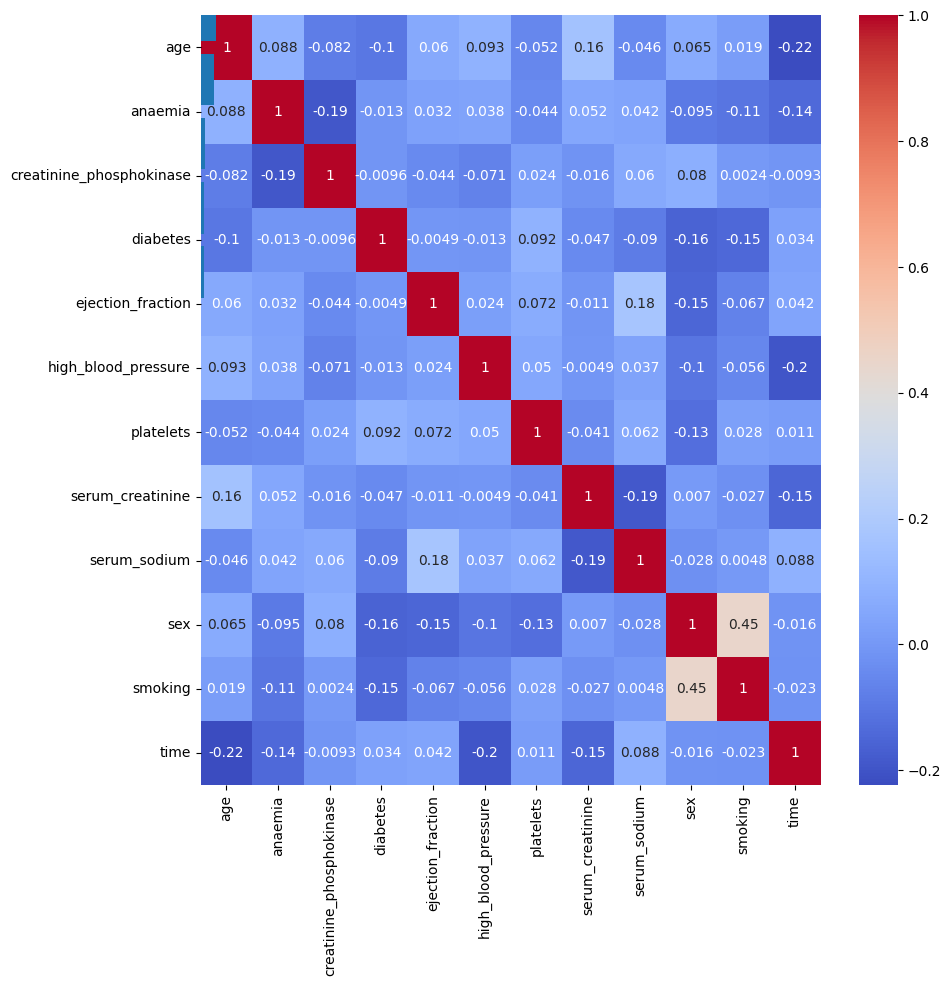

In [8]:
# correlation
correlation = df_features.corr()
correlation

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.barh(results_df_sorted['Feature'], results_df_sorted['Pearson Correlation'])

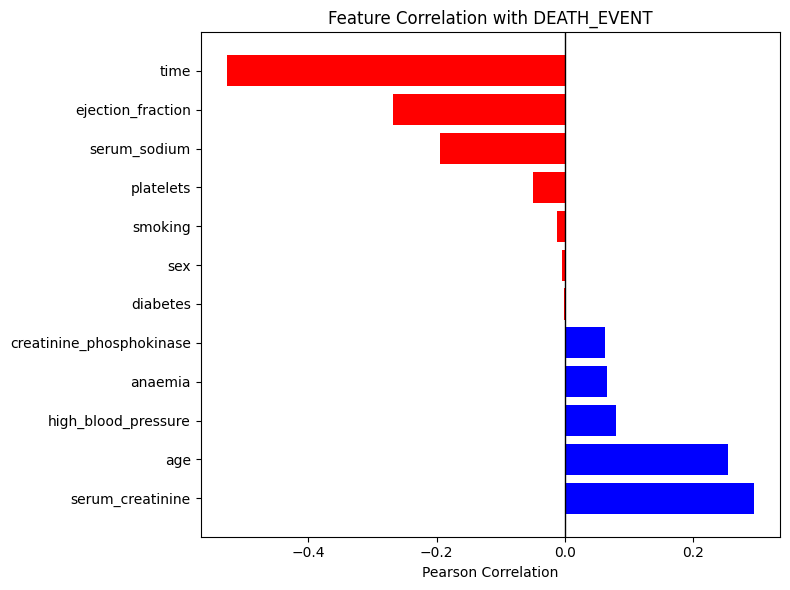

In [9]:
# visualize the correlation
import numpy as np
import matplotlib.pyplot as plt


colors = ['red' if c < 0 else 'blue' for c in results_df_sorted['Pearson Correlation']]

plt.figure(figsize=(8, 6))
plt.barh(results_df_sorted['Feature'], results_df_sorted['Pearson Correlation'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Feature Correlation with DEATH_EVENT')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()


## (2) Statistical Group Testing

**a. ttest_ind (scipy)**
* two-sample t-test
* formula: t = (x̄₁ - x̄₂ - D₀) / √(s₁²/n₁ + s₂²/n₂)
* t-test compares the MEAN of two groups (assumes ~normal distribution, sensitive to outliers)
* use when n is large enough (n≥30) or data looks roughly normal

In [21]:
from scipy.stats import ttest_ind

# two groups for two-sample t-test
survived_group = df[df['DEATH_EVENT'] == 0]
death_group = df[df['DEATH_EVENT'] == 1]

results = {'Feature': [], 'T-Statistic': [], 'P-Value': []}

# columns of features to evaluate 
numerical_columns = df.select_dtypes(include=[np.number]).columns.drop(['DEATH_EVENT'])

# t-test for each column
for column in numerical_columns:
    t_stat, p_value = ttest_ind(survived_group[column], death_group[column], equal_var=False) #  used welch's t-test
    results['Feature'].append(column)
    results['T-Statistic'].append(t_stat)
    results['P-Value'].append(p_value)

results_df = pd.DataFrame(results)
results_df

,Feature,T-Statistic,P-Value
0,age,-4.186210,4.735215e-05
1,anaemia,-1.136898,2.570643e-01
2,creatinine_phosphokinase,-0.901190,3.692160e-01
3,diabetes,0.033458,9.733450e-01
4,ejection_fraction,4.566983,9.647153e-06
5,high_blood_pressure,-1.347390,1.795643e-01
6,platelets,0.844785,3.993231e-01
7,serum_creatinine,-4.152639,6.398962e-05
8,serum_sodium,3.164501,1.872325e-03
9,sex,0.074238,9.409014e-01


In [22]:
def get_significant_features(results_df, threshold):
    return results_df[results_df['P-Value'] < threshold]['Feature'].tolist()

get_significant_features(results_df, 0.05)
# smaller p-value = the feature is more likely to actually predict death, not just by chance

['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']

**b. mannwhitneyu**
* compares the RANK/ORDER tendency of two groups (distribution-free, robust to outliers)
* H0: two groups come from the same distribution (no rank/order difference)
* process: combine → rank all values together → compare rank sums per group
* no normality assumption needed → use when data is skewed, has outliers, or n is small
* non-parametric equivalent of ttest_ind

In [19]:
from scipy.stats import mannwhitneyu

def mannwhitneyu_test(survived_group, death_group):
    results = {'Feature': [], 'U-Statistic': [], 'P-Value': []}
    
    numerical_columns = survived_group.select_dtypes(include=[np.number]).columns
    
    for column in numerical_columns:
        u_stat, p_value = mannwhitneyu(survived_group[column], death_group[column])
        results['Feature'].append(column)
        results['U-Statistic'].append(u_stat)
        results['P-Value'].append(p_value)
    
    return pd.DataFrame(results)

mannwhitneyu_test(survived_group, death_group)

,Feature,U-Statistic,P-Value
0,age,7121.0,1.667518e-04
1,anaemia,9059.0,2.529704e-01
2,creatinine_phosphokinase,9460.0,6.840400e-01
3,diabetes,9764.0,9.739131e-01
4,ejection_fraction,13176.5,7.368249e-07
5,high_blood_pressure,8953.5,1.710164e-01
6,platelets,10300.5,4.255585e-01
7,serum_creatinine,5298.0,1.580998e-10
8,serum_sodium,12261.5,2.927557e-04
9,sex,9787.0,9.412922e-01


**c. Question: Is this enough to just perform the ttest or mannwhitney test?**

In [23]:
# adjust p-vals based on multiple hypothesis tests (Benjamini Hochberg: FDR)
from statsmodels.stats.multitest import multipletests

# get p-values
pvals = results_df['P-Value'].values
fdr  = multipletests(pvals, method='fdr_bh')

# add to dataframe
results_df['p_fdr_bh'] = fdr[1]

# significance flags
results_df['significant_fdr'] = results_df['p_fdr_bh'] < 0.05
results_df.sort_values('p_fdr_bh')


# Answer:  When testing a single feature, alpha=0.05 is fine on its own. But when testing many features at once (10, 20+), the chance of 
# getting at least one "significant" result purely by luck increases a lot. FDR correction (Benjamini-Hochberg) adjusts the p-values to account for this,
# so only the features that are "truly" significant survive.

,Feature,T-Statistic,P-Value,p_fdr_bh,significant_fdr
11,time,11.006168,2.343276e-22,2.811931e-21,True
4,ejection_fraction,4.566983,9.647153e-06,5.788292e-05,True
0,age,-4.186210,4.735215e-05,1.894086e-04,True
7,serum_creatinine,-4.152639,6.398962e-05,1.919689e-04,True
8,serum_sodium,3.164501,1.872325e-03,4.493580e-03,True
5,high_blood_pressure,-1.347390,1.795643e-01,3.591286e-01,False
1,anaemia,-1.136898,2.570643e-01,4.406817e-01,False
2,creatinine_phosphokinase,-0.901190,3.692160e-01,5.324308e-01,False
6,platelets,0.844785,3.993231e-01,5.324308e-01,False
3,diabetes,0.033458,9.733450e-01,9.733450e-01,False


## (3) Random Forest Feature Importance

Machine learning models can rank features by their predictive power

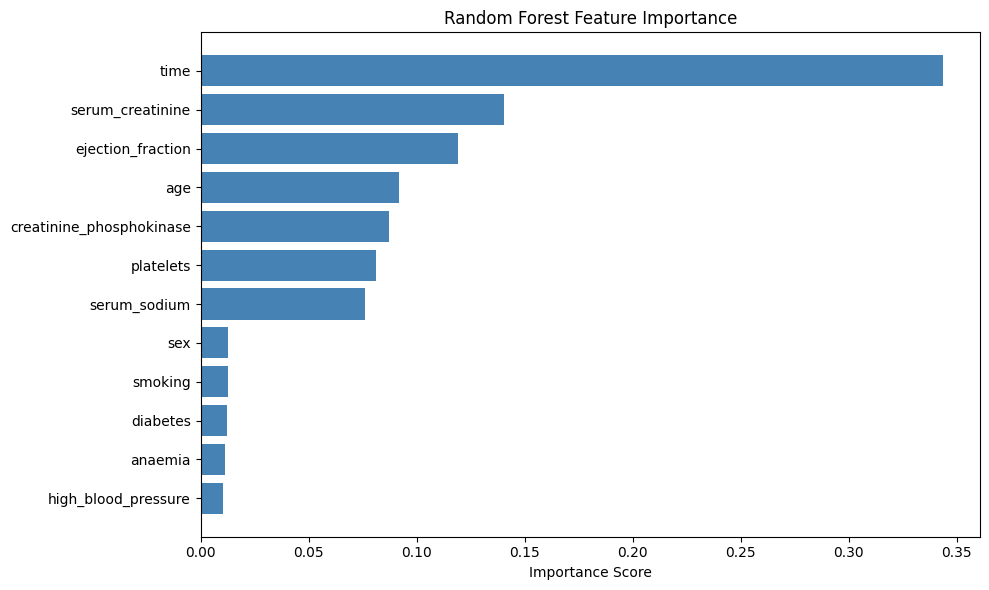

Top 5 Features:


,Feature,Importance
11,time,0.343650
7,serum_creatinine,0.140594
4,ejection_fraction,0.119169
0,age,0.092071
2,creatinine_phosphokinase,0.087158


In [14]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("Top 5 Features:")
importance_df.sort_values('Importance', ascending=False).head()

## (4) Feature Variance Analysis

Features with very low variance may not be useful for prediction. This is supplementary material for those interested.

In [24]:
# Variance and Coefficient of Variation (CV = std/mean)
from sklearn.preprocessing import StandardScaler

variance_df = pd.DataFrame({
    'Feature': X.columns,
    'Variance': X.var(),
    'Std': X.std(),
    'Mean': X.mean(),
    'CV': X.std() / X.mean()  # coefficient of variation
}).sort_values('Variance', ascending=False)

print("Feature Variance Summary:")
print("CV (Coefficient of Variation) = Std/Mean - higher means more spread relative to mean\n")
variance_df

Feature Variance Summary:
CV (Coefficient of Variation) = Std/Mean - higher means more spread relative to mean



,Feature,Variance,Std,Mean,CV
platelets,platelets,9.565669e+09,97804.236869,263358.029264,0.371374
creatinine_phosphokinase,creatinine_phosphokinase,9.414586e+05,970.287881,581.839465,1.667621
time,time,6.023965e+03,77.614208,130.260870,0.595837
age,age,1.414865e+02,11.894809,60.833893,0.195529
ejection_fraction,ejection_fraction,1.400635e+02,11.834841,38.083612,0.310759
serum_sodium,serum_sodium,1.946996e+01,4.412477,136.625418,0.032296
serum_creatinine,serum_creatinine,1.070211e+00,1.034510,1.393880,0.742180
anaemia,anaemia,2.461224e-01,0.496107,0.431438,1.149892
diabetes,diabetes,2.441023e-01,0.494067,0.418060,1.181808
high_blood_pressure,high_blood_pressure,2.286144e-01,0.478136,0.351171,1.361550


In [25]:
# get significant features function
def get_significant_features(results_df, threshold=0.05):
    return results_df[results_df['P-Value'] < threshold]['Feature'].tolist()

print("Significant features (p<0.05):", get_significant_features(results_df, 0.05))

Significant features (p<0.05): ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']


In [26]:
# Mann-Whitney U test for all features
from scipy.stats import mannwhitneyu

mw_results = []
for col in df.select_dtypes(include=[np.number]).columns.drop(['DEATH_EVENT']):
    u_stat, p_val = mannwhitneyu(survived_group[col], death_group[col], alternative='two-sided')
    mw_results.append({'Feature': col, 'U-Statistic': u_stat, 'P-Value': p_val})

mw_df = pd.DataFrame(mw_results).sort_values('P-Value')
mw_df['Significant'] = mw_df['P-Value'] < 0.05
mw_df

,Feature,U-Statistic,P-Value,Significant
11,time,16288.5,6.852197e-21,True
7,serum_creatinine,5298.0,1.580998e-10,True
4,ejection_fraction,13176.5,7.368249e-07,True
0,age,7121.0,1.667518e-04,True
8,serum_sodium,12261.5,2.927557e-04,True
5,high_blood_pressure,8953.5,1.710164e-01,False
1,anaemia,9059.0,2.529704e-01,False
6,platelets,10300.5,4.255585e-01,False
2,creatinine_phosphokinase,9460.0,6.840400e-01,False
10,smoking,9867.0,8.281900e-01,False


## (5) Summary

1. **Correlation Analysis**: Pearson correlation measures linear relationships between features and target
2. **Statistical Tests**: 
   - T-test: Compares means between two groups (assumes normality)
   - Mann-Whitney U: Non-parametric alternative (no normality assumption)
3. **Multiple Testing Correction**: FDR (Benjamini-Hochberg) adjusts p-values when testing many hypotheses
4. **Significant Features**: time, ejection_fraction, serum_creatinine, age, serum_sodium